# PyJST in Google Colab

This notebook installs PyJST from GitHub, runs its straight-channel and compression-corner demonstration cases, and displays pressure/convergence figures.

> **GPU note:** Colab's GPU runtime can be selected from **Runtime → Change runtime type**, but the current PyJST solver uses NumPy and therefore runs on the CPU. A GPU backend will be added separately.

In [1]:
# Install the package and its optional plotting dependency from GitHub.
%pip install -q --upgrade --force-reinstall "git+https://github.com/VishalKandala/PyJST.git" "matplotlib>=3.7" "cupy-cuda12x>=13.0"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
from dataclasses import replace

from pyjst import (
    CartesianGrid,
    CompressionCornerCase,
    JSTParameters,
    freestream_initial_state,
    solve,
    uniform_supersonic_case,
)
from pyjst.postprocess import mach_number, plot_solution
from pyjst.performance import benchmark_suite, save_benchmark_figure, write_benchmark_results

import cupy as cp
device = cp.cuda.runtime.getDeviceProperties(cp.cuda.Device().id)["name"].decode()
print(f"CuPy {cp.__version__} on {device}")


CuPy 14.0.1 on NVIDIA A100-SXM4-40GB


## Straight channel: uniform Mach-2 flow

This exact-preservation case should have a pressure ratio of one everywhere and a zero residual.

normalized residual: 0.000e+00


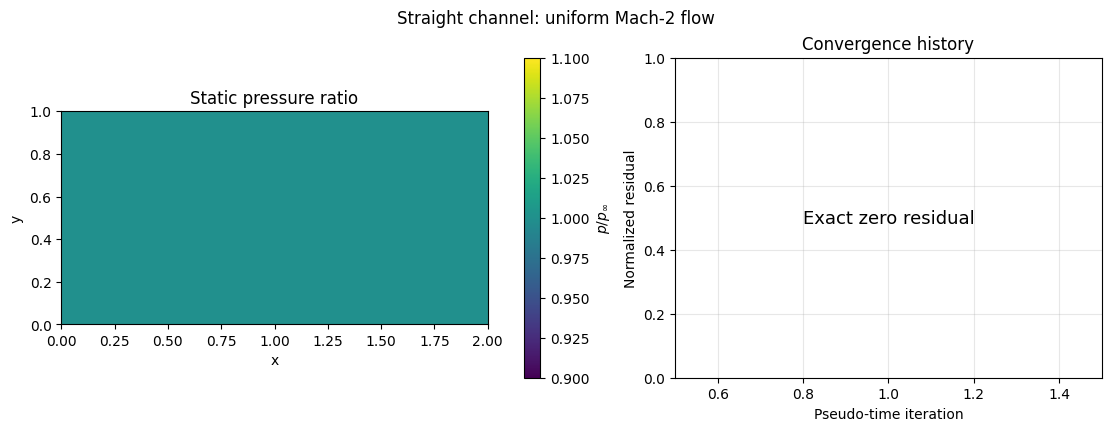

In [3]:
channel_case = replace(uniform_supersonic_case(), numerics=JSTParameters(max_iterations=1))
channel_grid = CartesianGrid(channel_case.grid)
channel_result = solve(freestream_initial_state(channel_grid, channel_case), channel_grid, channel_case)

print(f"normalized residual: {channel_result.residual_history[-1]:.3e}")
plot_solution(channel_result, channel_grid, channel_case, title="Straight channel: uniform Mach-2 flow");

## Mach-2, 10-degree compression corner

The body-fitted mesh captures the pressure rise and oblique shock downstream of the corner. The 500-iteration result is a visual demonstration rather than a fully converged validation study.

normalized residual after 500 iterations: 5.475e-01
Mach-number range: 1.580 to 2.073


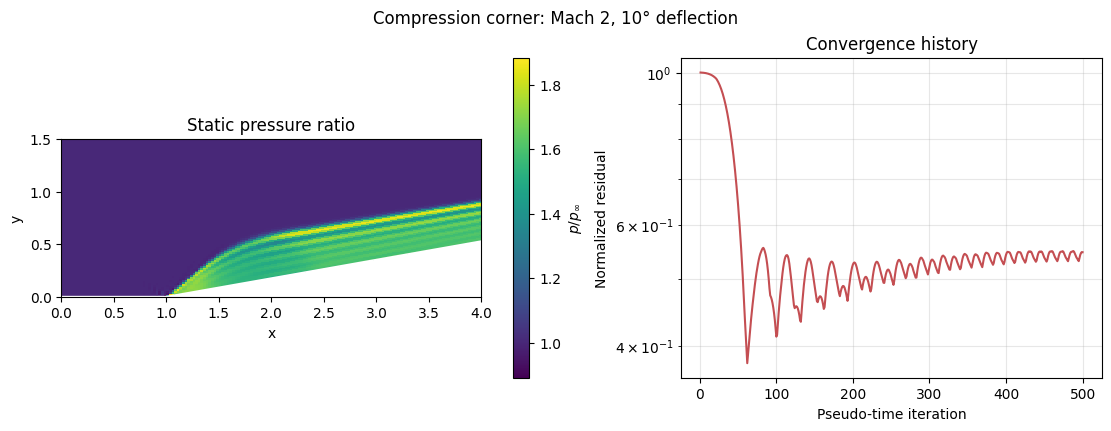

In [4]:
corner_definition = CompressionCornerCase(nx=160, ny=80)
corner_case = replace(
    corner_definition.solver_case(),
    numerics=JSTParameters(cfl=0.4, cfl_initial=0.05, cfl_ramp_iterations=100, max_iterations=500),
)
corner_grid = corner_definition.grid()
corner_result = solve(freestream_initial_state(corner_grid, corner_case), corner_grid, corner_case)

print(f"normalized residual after {corner_result.iterations} iterations: {corner_result.residual_history[-1]:.3e}")
print(f"Mach-number range: {mach_number(corner_result.conservative, corner_grid, corner_case).min():.3f} to {mach_number(corner_result.conservative, corner_grid, corner_case).max():.3f}")
plot_solution(corner_result, corner_grid, corner_case, title="Compression corner: Mach 2, 10° deflection");

## CuPy GPU solve and CPU/GPU in-situ benchmark

This section requires a Colab GPU runtime. The GPU solve returns its final state to the host only after the pseudo-time march, allowing the existing Matplotlib post-processing to be reused. The final benchmark cell compares NumPy CPU and CuPy GPU execution in one runtime.

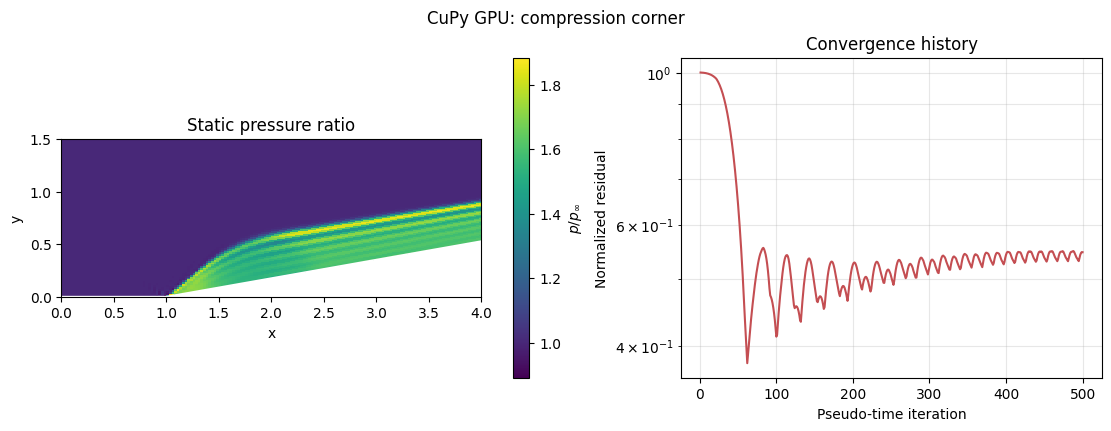

In [5]:
gpu_result = solve(
    freestream_initial_state(corner_grid, corner_case),
    corner_grid,
    corner_case,
    backend="cupy",
)
plot_solution(gpu_result, corner_grid, corner_case, title="CuPy GPU: compression corner");

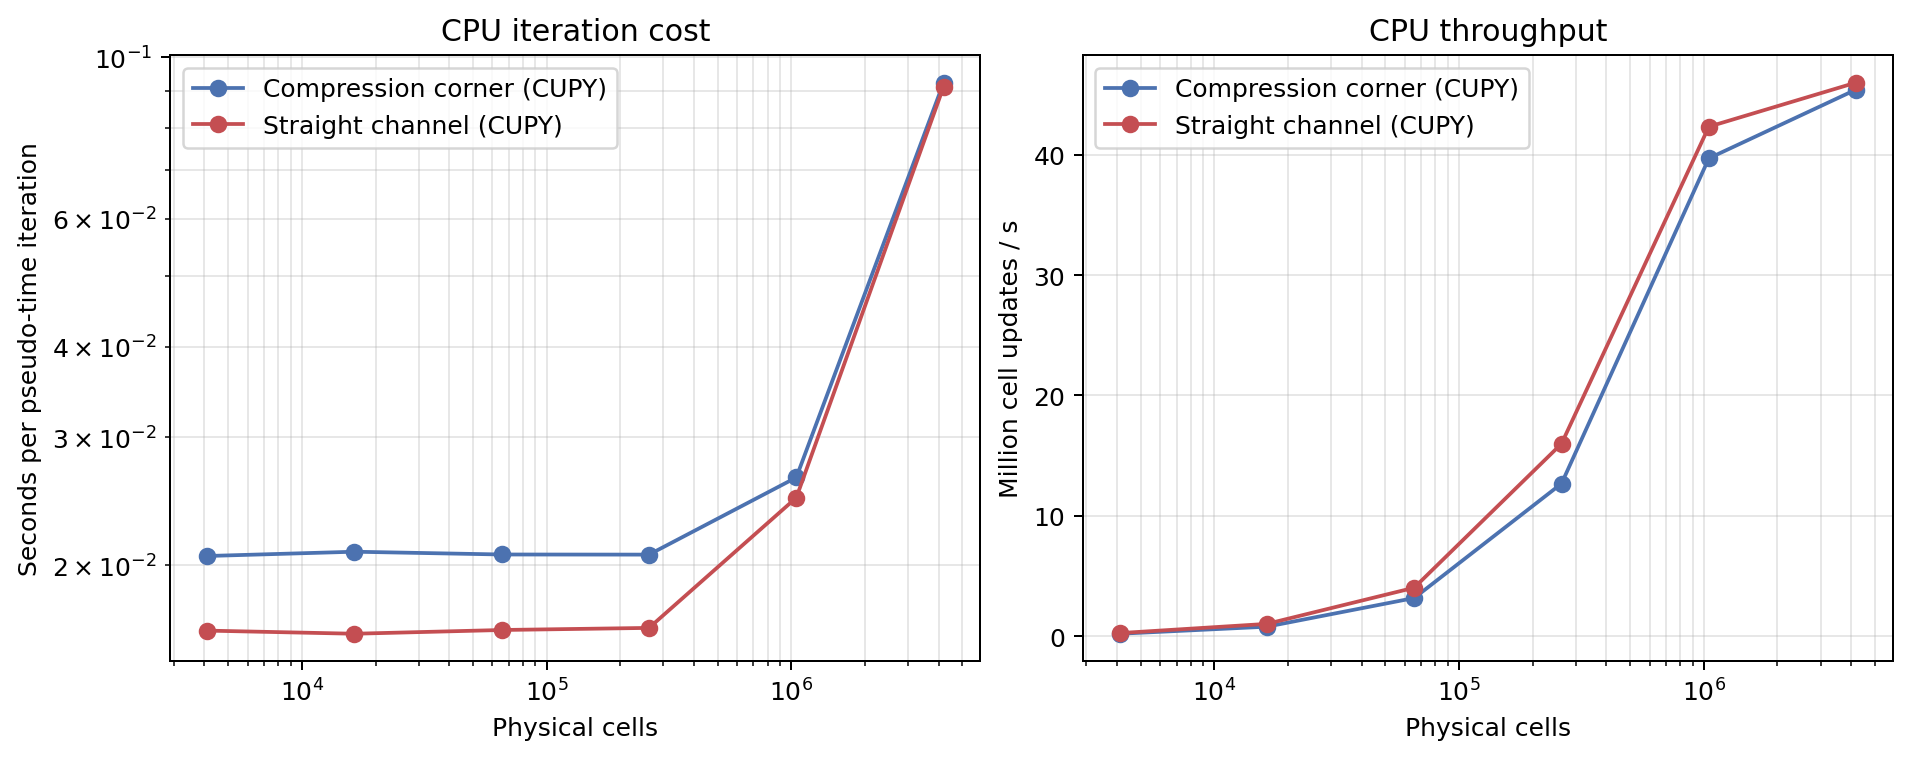

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# Both backends run in this one GPU-runtime session. CUDA timings synchronize
# the stream and exclude one-time setup and host/device copies.
resolutions = (64, 128, 256, 512, 1024, 2048)
cpu_samples = benchmark_suite(resolutions, repeats=2, warmup_iterations=1, backend="numpy")
gpu_samples = benchmark_suite(resolutions, repeats=3, warmup_iterations=1, backend="cupy")
comparison_samples = cpu_samples + gpu_samples

write_benchmark_results(comparison_samples, "cpu-gpu-scaling.json")
save_benchmark_figure(comparison_samples, "cpu-gpu-scaling.png")

from IPython.display import Image, display
display(Image(filename="cpu-gpu-scaling.png"))

try:
    from google.colab import files
    files.download("cpu-gpu-scaling.json")
    files.download("cpu-gpu-scaling.png")
except ImportError:
    print("Saved cpu-gpu-scaling.json and cpu-gpu-scaling.png in the notebook working directory.")